
Features used: ['age', 'gender', 'smoker', 'known_blood_sugar', 'known_cholesterol', 'under_treatment', 'health_condition']
Total samples: 15219

Training set : 12,175 rows
Test set     : 3,044 rows
Cross-validated R² scores (systolic BP): [0.10898281 0.03700077 0.09566645 0.14069751 0.12827926]
Mean CV R²: 0.10212535973717132
--- Model Evaluation ---
Systolic BP R²: 0.118, MAE: 14.05, RMSE: 17.98
Diastolic BP R²: 0.018, MAE: 10.70, RMSE: 14.43

Feature Importance:
          feature  importance
              age    0.673348
  under_treatment    0.123412
           gender    0.083019
 health_condition    0.052752
known_blood_sugar    0.024567
known_cholesterol    0.024469
           smoker    0.018432


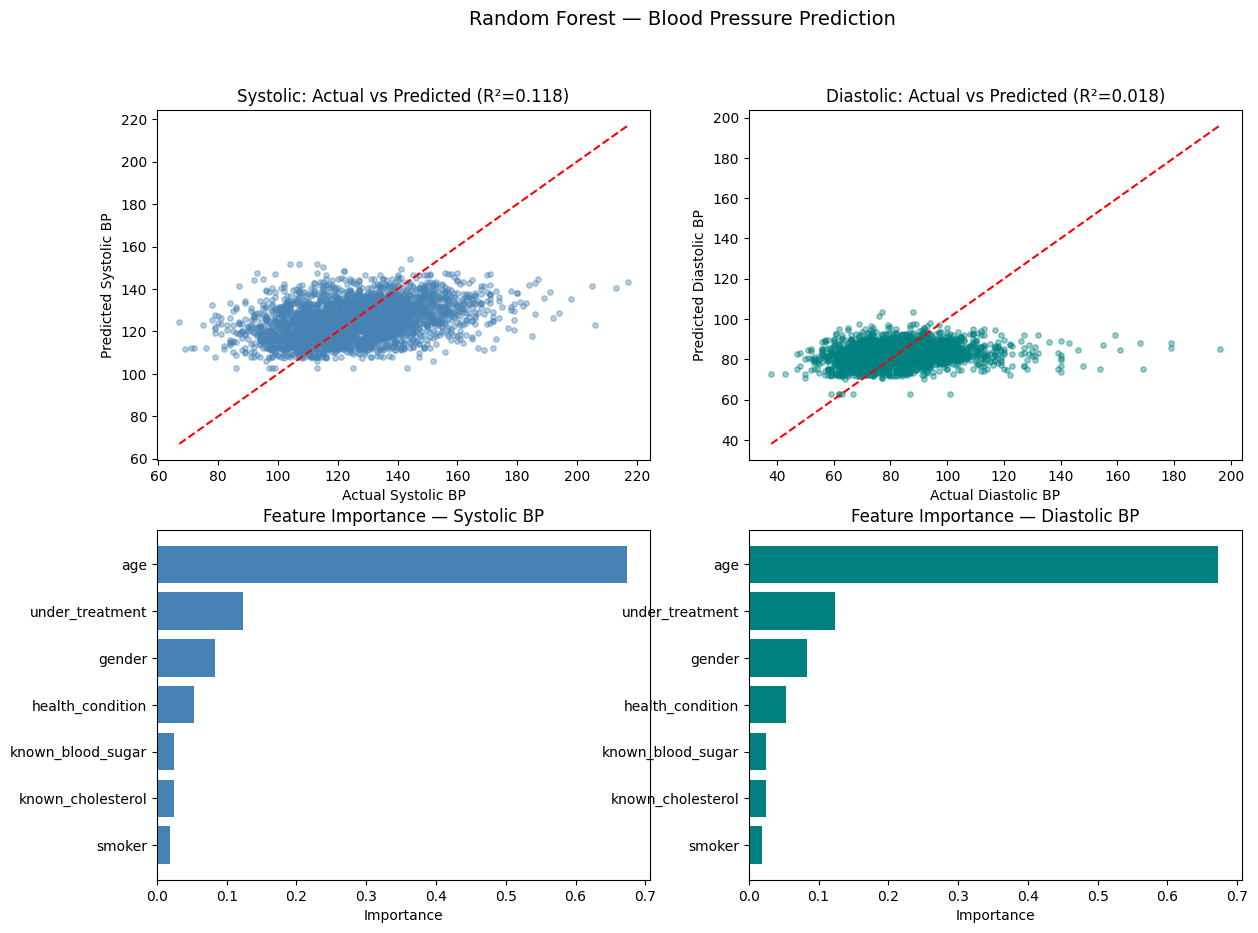

Figure saved at: ../presentation/figures/bp_prediction_fig.png

MODEL SUMMARY
                            Systolic  Diastolic
R²                            0.1183     0.0178
MAE (mmHg)                     14.05      10.70
RMSE (mmHg)                    17.98      14.43
Train size                    12,175
Test size                      3,044


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data
data = pd.read_csv("../data/processed/final_dataset_numeric.csv")

# Define features 
FEATURES = [
    'age',
    'gender',
    'smoker',
    'known_blood_sugar',
    'known_cholesterol',
    'under_treatment',
    'health_condition'
]

X = data[FEATURES]
y = data[['bp_systolic', 'bp_diastolic']]  # multi-output target

print(f"\nFeatures used: {FEATURES}")
print(f"Total samples: {len(X)}")

# Train/Test Split
(X_train, X_test,
 y_train, y_test) = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42    
)

print(f"\nTraining set : {len(X_train):,} rows")
print(f"Test set     : {len(X_test):,} rows")

# Build RF model
rf = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,max_depth=None
)

from sklearn.model_selection import cross_val_score

# Cross-validation
scores = cross_val_score(rf, X, y['bp_systolic'], cv=5, scoring='r2')
print("Cross-validated R² scores (systolic BP):", scores)
print("Mean CV R²:", scores.mean())

# fitting
rf.fit(X_train, y_train)
#predict
y_pred = rf.predict(X_test)

# Evaluate the model
# R², MAE, RMSE for systolic and diastolic BP
r2_sys = r2_score(y_test['bp_systolic'], y_pred[:,0])
r2_dia = r2_score(y_test['bp_diastolic'], y_pred[:,1])

mae_sys = mean_absolute_error(y_test['bp_systolic'], y_pred[:,0])
mae_dia = mean_absolute_error(y_test['bp_diastolic'], y_pred[:,1])

rmse_sys = np.sqrt(mean_squared_error(y_test['bp_systolic'], y_pred[:,0]))
rmse_dia = np.sqrt(mean_squared_error(y_test['bp_diastolic'], y_pred[:,1]))

print(f"--- Model Evaluation ---")
print(f"Systolic BP R²: {r2_sys:.3f}, MAE: {mae_sys:.2f}, RMSE: {rmse_sys:.2f}")
print(f"Diastolic BP R²: {r2_dia:.3f}, MAE: {mae_dia:.2f}, RMSE: {rmse_dia:.2f}")

# Feature Importance
imp = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(imp.to_string(index=False))

# Plots 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest — Blood Pressure Prediction', fontsize=14)

# Systolic: Actual vs Predicted
axes[0,0].scatter(y_test['bp_systolic'], y_pred[:,0], alpha=0.4, s=15, color='steelblue')
axes[0,0].plot([y_test['bp_systolic'].min(), y_test['bp_systolic'].max()],
               [y_test['bp_systolic'].min(), y_test['bp_systolic'].max()], 'r--', lw=1.5)
axes[0,0].set_xlabel('Actual Systolic BP')
axes[0,0].set_ylabel('Predicted Systolic BP')
axes[0,0].set_title(f'Systolic: Actual vs Predicted (R²={r2_sys:.3f})')

# Diastolic: Actual vs Predicted
axes[0,1].scatter(y_test['bp_diastolic'], y_pred[:,1], alpha=0.4, s=15, color='teal')
axes[0,1].plot([y_test['bp_diastolic'].min(), y_test['bp_diastolic'].max()],
               [y_test['bp_diastolic'].min(), y_test['bp_diastolic'].max()], 'r--', lw=1.5)
axes[0,1].set_xlabel('Actual Diastolic BP')
axes[0,1].set_ylabel('Predicted Diastolic BP')
axes[0,1].set_title(f'Diastolic: Actual vs Predicted (R²={r2_dia:.3f})')

# Feature importance — Systolic
axes[1,0].barh(imp['feature'], imp['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance')
axes[1,0].set_title('Feature Importance — Systolic BP')
axes[1,0].invert_yaxis()

# Feature importance — Diastolic
axes[1,1].barh(imp['feature'], imp['importance'], color='teal')
axes[1,1].set_xlabel('Importance')
axes[1,1].set_title('Feature Importance — Diastolic BP')
axes[1,1].invert_yaxis()

# Saving figure
fig_path = "../presentation/figures/bp_prediction_fig.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# Summary 
print("\n" + "="*45)
print("MODEL SUMMARY")
print("="*45)
print(f"{'':25} {'Systolic':>10} {'Diastolic':>10}")
print(f"{'R²':25} {r2_sys:>10.4f} {r2_dia:>10.4f}")
print(f"{'MAE (mmHg)':25} {mae_sys:>10.2f} {mae_dia:>10.2f}")
print(f"{'RMSE (mmHg)':25} {rmse_sys:>10.2f} {rmse_dia:>10.2f}")
print(f"{'Train size':25} {len(X_train):>10,}")
print(f"{'Test size':25} {len(X_test):>10,}")